Let's try to identify Lorenz nonlinear system. The data will be generated directly from the formula, with 0.1% Gaussian noise, and then We will try to identify the equations

In [147]:
import numpy as np
import pysindy as ps
from pysindy import SINDy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pysindy.optimizers import STLSQ
from pysindy.differentiation import SpectralDerivative



True dynamics:

In [148]:
def true_dynamics(t,y):
    return [10*(y[1]-y[0]),y[0]*(28-y[2]) - y[1], y[0]*y[1] - (8/3)*y[2]]

In [149]:
# Definisanje vremenske ose
t_span = [0, 50]
t_eval = np.linspace(0, 50, 5000)
x0 = [1.0, 1.0, 1.0]

# Integracija
sol = solve_ivp(true_dynamics, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

In [150]:
# Izvlačenje čistih podataka
x_train = sol.y.T 

noise_level = 0.001
noise = noise_level * np.std(x_train, axis=0) * np.random.standard_normal(x_train.shape)

# Kreiranje "zagađenih" podataka za SINDy
x_noisy = x_train + noise

In [151]:
# 1. Pravilno definiši diferencijaciju
dt = t_eval[1]-t_eval[0]

sindy_diff = ps.SmoothedFiniteDifference(
    smoother_kws={'window_length': 10, 'polyorder': 3}
)

poly_lib = ps.PolynomialLibrary(degree=2, include_bias=False)

optimizer = STLSQ(threshold=0.01, normalize_columns=True)

# 4. Model
model = ps.SINDy(
    differentiation_method=sindy_diff,
    feature_library=poly_lib,
    optimizer=optimizer
)

model.fit(x_noisy, t=dt, feature_names=["x", "y", "z"])
model.print()


(x)' = -10.084 x +  10.057 y +  0.001 x^2 + -0.001 x y +  0.003 x z + -0.003 y z
(y)' =  27.722 x + -0.923 y + -0.006 z + -0.001 x^2 +  0.001 x y + -0.992 x z + -0.001 y^2 + -0.001 y z
(z)' = -0.065 x +  0.044 y + -2.598 z +  0.034 x^2 +  0.962 x y +  0.002 x z +  0.009 y^2 + -0.001 y z + -0.003 z^2


STSLQ didn't cut off small coefficients, maybe because of the scaling while adding noise to the data

In [152]:
try:
    x_sim = model.simulate(x0, t_eval)
except ValueError as e:
    print("NUmerically unstable simulation.")

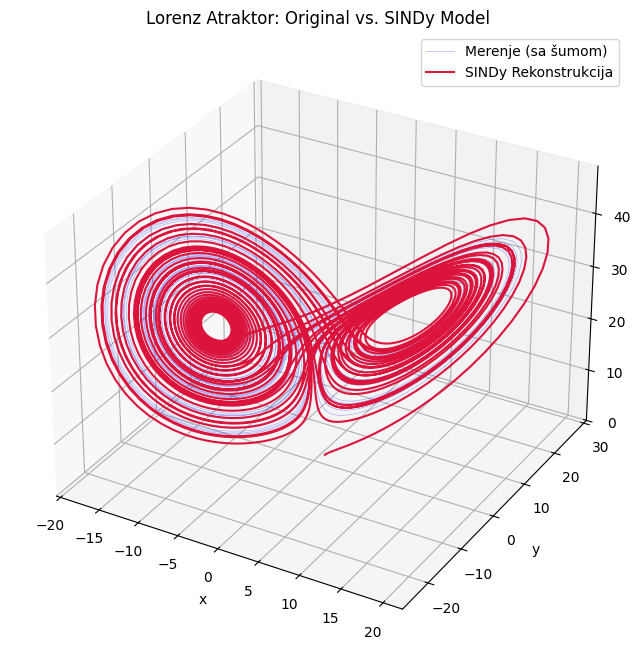

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot originalne podatke (sa šumom) - plava
ax.plot(x_noisy[:, 0], x_noisy[:, 1], x_noisy[:, 2], 
        color='blue', alpha=0.3, label='Merenje (sa šumom)', linewidth=0.5)

# Plot SINDy identifikaciju - jarka boja
ax.plot(x_sim[:, 0], x_sim[:, 1], x_sim[:, 2], 
        color='crimson', label='SINDy Rekonstrukcija', linewidth=1.5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz Atraktor: Original vs. SINDy Model")
ax.legend()
plt.show()

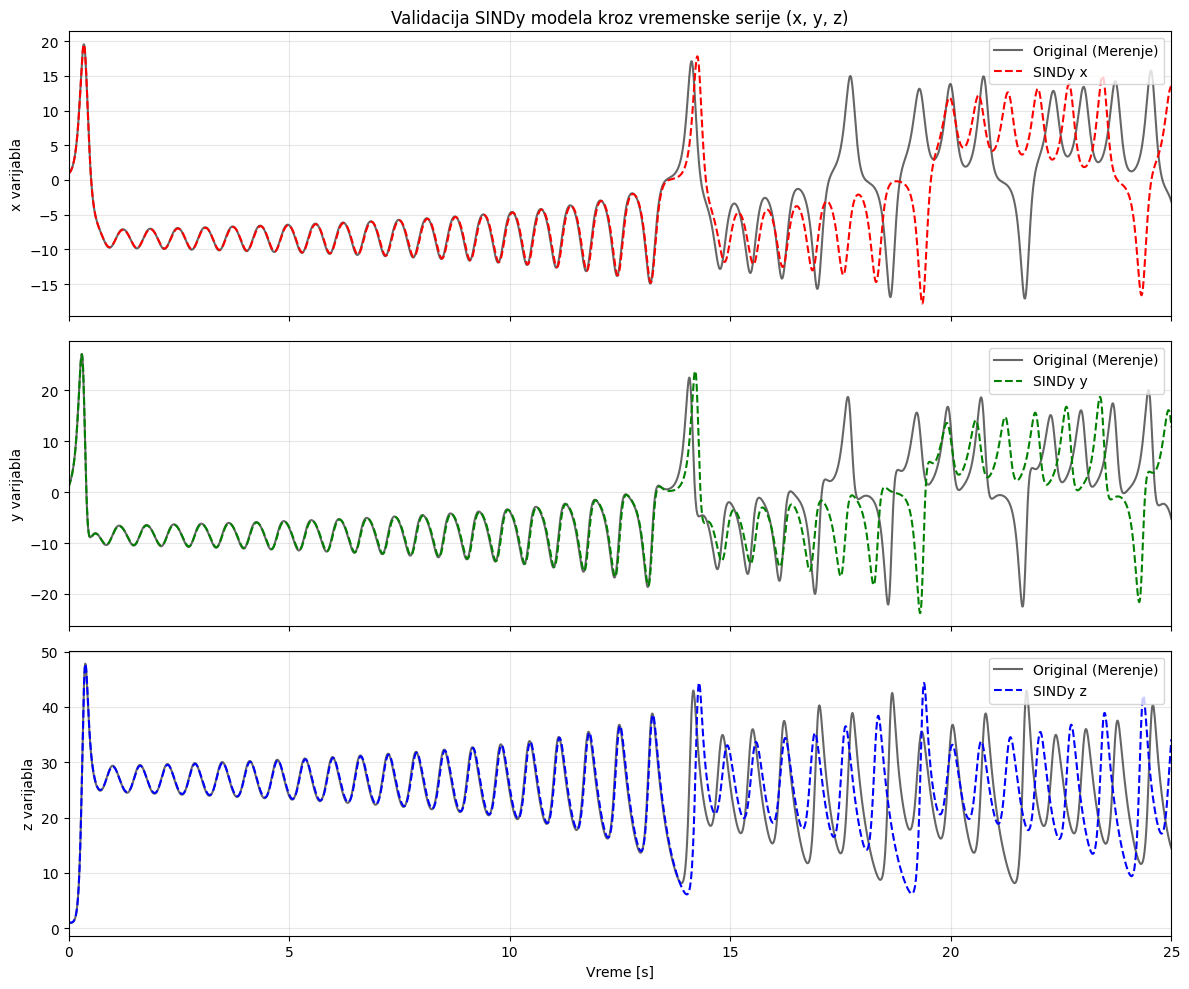

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Lista varijabli i boja za lakšu iteraciju
variables = ['x', 'y', 'z']
colors = ['r', 'g', 'b'] # SINDy boje

for i in range(3):
    # Originalni podaci (crna linija)
    axs[i].plot(t_eval, x_train[:, i], 'k', label='Original (Merenje)', alpha=0.6)
    
    # SINDy simulacija (isprekidana linija u boji)
    axs[i].plot(t_eval, x_sim[:, i], color=colors[i], linestyle='--', label=f'SINDy {variables[i]}')
    
    axs[i].set_ylabel(f'{variables[i]} varijabla')
    axs[i].legend(loc='upper right')
    axs[i].grid(alpha=0.3)

# Podešavanja za celu sliku
plt.xlim([0, 25]) 
plt.xlabel("Vreme [s]")
axs[0].set_title("Validacija SINDy modela kroz vremenske serije (x, y, z)")

plt.tight_layout()
plt.show()